In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import blimpy as bl 
import glob
import os
%matplotlib inline

In [2]:
df = pd.read_csv('/datax/scratch/benjb/bl_nearby_stars/BL_star_targets_all_sky.csv')
df

,Name,RA,DEC,Vmag,Sp.Type,dist (pc),ObsDate,Unnamed: 7
0,HIP2,0 0 1.22,-19 29 55,9.27,K3V,45.6,12/13/2020,NaN
1,HIP171,0 2 11.0,27 4 41,5.80,G3V,12.4,11/13/2020,NaN
2,HIP194,0 2 29.6,8 29 6,5.70,F0V,37.6,08/21/2020,NaN
3,HIP400,0 4 56.7,23 16 10,7.82,G9V,25.6,01/19/2020,NaN
4,HIP428,0 5 12.2,45 47 9,9.95,M2,11.4,12/01/2019,NaN
...,...,...,...,...,...,...,...,...
1176,HIP117795,23 53 20.0,59 56 42,10.40,K8,27.3,07/04/2019,NaN
1177,HIP117946,23 55 26.8,22 11 33,8.77,K0,25.4,08/02/2019,NaN
1178,HIP118162,23 58 6.74,50 26 55,6.72,G5,24.1,07/04/2019,NaN
1179,HIP118212,23 58 44.5,46 43 44,9.57,M0,17.3,07/04/2019,NaN


In [3]:
dfu = df.drop(983) # remove duplicate entry for HIP 97222
dfu

,Name,RA,DEC,Vmag,Sp.Type,dist (pc),ObsDate,Unnamed: 7
0,HIP2,0 0 1.22,-19 29 55,9.27,K3V,45.6,12/13/2020,NaN
1,HIP171,0 2 11.0,27 4 41,5.80,G3V,12.4,11/13/2020,NaN
2,HIP194,0 2 29.6,8 29 6,5.70,F0V,37.6,08/21/2020,NaN
3,HIP400,0 4 56.7,23 16 10,7.82,G9V,25.6,01/19/2020,NaN
4,HIP428,0 5 12.2,45 47 9,9.95,M2,11.4,12/01/2019,NaN
...,...,...,...,...,...,...,...,...
1176,HIP117795,23 53 20.0,59 56 42,10.40,K8,27.3,07/04/2019,NaN
1177,HIP117946,23 55 26.8,22 11 33,8.77,K0,25.4,08/02/2019,NaN
1178,HIP118162,23 58 6.74,50 26 55,6.72,G5,24.1,07/04/2019,NaN
1179,HIP118212,23 58 44.5,46 43 44,9.57,M0,17.3,07/04/2019,NaN


In [4]:
ravec = dfu['RA'].values
decvec = dfu['DEC'].values
dvec = dfu['dist (pc)'].values

In [5]:
import astropy
print(ravec)
a_ravec = np.array([astropy.coordinates.Angle(ra + ' hours').radian for ra in ravec])
a_decvec = np.array([astropy.coordinates.Angle(dec + ' degrees').radian for dec in decvec])
print(a_ravec)

['0 0 1.22 ' '0 2 11.0 ' '0 2 29.6 ' ... '23 58 6.74 ' '23 58 44.5 '
 '23 59 47.7 ']
[8.87209036e-05 9.52658883e-03 1.08792190e-02 ... 6.27494881e+00
 6.27769479e+00 6.28229083e+00]


In [6]:
a_ravec_modified = []
for a in a_ravec:
    if a >= np.pi:
        new_a = a - 2*np.pi
    else:
        new_a = a
    a_ravec_modified.append(new_a)

In [7]:
print(a_decvec.min())
print(-20*np.pi/180)

-0.3486828475907893
-0.3490658503988659


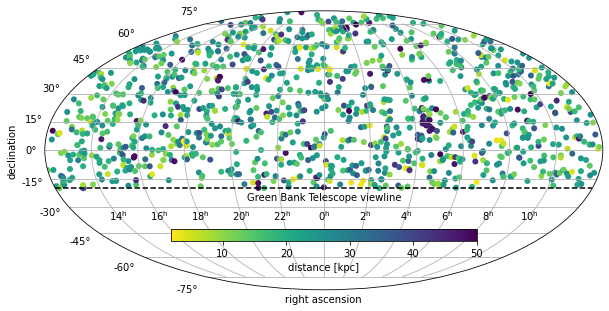

In [8]:
fig = plt.figure(figsize=(10,6))
ax = plt.axes(projection="mollweide")
ax.grid(True)

s = ax.scatter(a_ravec_modified, a_decvec, c=dvec, cmap='viridis_r', lw=0)
plt.axhline(-20*np.pi/180, color='k', ls='--')
ax.text(0, -25*np.pi/180, 'Green Bank Telescope viewline', ha='center', va='center')

cax = ax.inset_axes([-120*np.pi/180, -50*np.pi/180, 240*np.pi/180, 7*np.pi/180], transform=ax.transData)
fig.colorbar(s, cax=cax, orientation='horizontal', label='distance [kpc]')
ax.set_xlabel('right ascension')
ax.set_ylabel('declination')
#help(ax.spines['geo'])
#print(ax.spines['geo'].get_position())
#ax.spines['geo'].set_position(('data', -35*np.pi/180))
#ax.tick_params(axis='x', which='major', pad=50)
ax.set_xticklabels([])
xticklabelvec = [r'14$^\mathrm{h}$', 
                    r'16$^\mathrm{h}$', 
                    r'18$^\mathrm{h}$',
                    r'20$^\mathrm{h}$', 
                    r'22$^\mathrm{h}$', 
                    r'0$^\mathrm{h}$',
                    r'2$^\mathrm{h}$',
                    r'4$^\mathrm{h}$',
                    r'6$^\mathrm{h}$',
                    r'8$^\mathrm{h}$', 
                    r'10$^\mathrm{h}$']
xtickvec = ax.get_xticks()
#print(xtickvec)
for i, x in enumerate(xticklabelvec):
    xpos = xtickvec[i]
    ax.text(xpos, -35*np.pi/180, x, ha='center', va='center')
plt.savefig('/datax/scratch/benjb/bl_nearby_stars/Fig_sky_distribution_of_sources.pdf', bbox_inches='tight')
plt.show()

In [9]:
print(dvec.max())

50.0
